# SIOC 217C: Climate and Climate Change
## Homework #1
### Willa Tobin
Consider an atmosphere filled by an absorber with uniform mixing ratio that absorbs equally at all terrestrial wavelengths. The optical thickness for this absorber is zero at the top of the atmosphere and has value τ0 at the surface. For simplicity, assume that atmospheric pressure and density vary exponentially with constant scale height H and ignore any variation of scale height with temperature. Assume the surface is a blackbody and the atmosphere is a graybody (e.g., emits like a blackbody scaled by a fraction equal to emissivity) at terrestrial wavelengths. Also assume that optical thickness can be multiplied by a constant “diffusivity factor” r in order to take into account radiation goes at all angles of the hemisphere and not just in the vertical direction. For this assignment, it will be most convenient to create a model with layers that have equal thickness in height coordinates.


- uniform mixing ratio
- absorbs equally at all wavelengths
- optical thickness is zero at TOA, tau_0 at SFC
- constant scale height H
    - pressure and density vary exponentially
- SFC blackbody (terrestrial wavelengths)
- ATM greybody (terrestrial wavelengths)
- diffusivity factor - r

Create a model with layers that have equal thickness in height coordinates

In [242]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [243]:
# Physical constants
SIGMA = 5.670374419e-8  # W m-2 K-4

# Model parameters
H = 8000                # scale height [m]
r = 1.66                # diffusivity factor
dz = -100               # layer thickness [m]
z = np.arange(0, 5*H)
tau_0 = np.array([0.1, 0.3, 1, 3])

# Surface temperatures
T_SFC = 290             # surface temperature for Q1-8 [K]
TS = 288                # surface temperature for Q9-11 [K]

# CO2 scenario parameters
GAMMA = 52              # lapse rate parameter [K]
TAU_0_1 = 2.2           # 1xCO2 optical thickness
TAU_0_2 = 2.3           # 2xCO2 optical thickness


def vertical_profile(z, p_0, H):
    return p_0 * np.exp(-z / H)

def transmittance(t_z, r):
    return np.exp(-r * t_z)

def black_body_flux(temp):
    return SIGMA * temp**4

def transmitted_surface_flux(t_0, t_z, r):
    b0 = black_body_flux(t_0)
    return b0 * transmittance(t_z, r)[0]

def emiss(r, t_0, z, dz, H):
    return -r * t_0 * dz * np.exp(-z / H) / H

def B_z_inf(T0, r, dz, t_0, z, H, sfc=False):
    b = black_body_flux(temp=T0)
    if sfc:
        emis = 1
    else:
        emis = emiss(r=r, t_0=t_0, z=z, dz=dz, H=H)
    tau = vertical_profile(z=z, p_0=t_0, H=H)
    trans = transmittance(t_z=tau, r=r)
    return b * emis * trans

def tau_max(r):
    return 1 / r

def z_max_scaled(r, t_0):
    return -np.log(1 / (r * t_0))

def emiss_z_max(dz, H):
    return -dz / H

def tau_down(z, p_0, H):
    return p_0 * (1 - np.exp(-z / H))

def B_z_sfc(T0, r, dz, t_0, z, H):
    tau = tau_down(z=z, p_0=t_0, H=H)
    b = black_body_flux(temp=T0)
    emis = emiss(r=r, t_0=t_0, z=z, dz=dz, H=H)
    trans = transmittance(t_z=tau, r=r)
    return b * emis * trans

def temp_profile(T0, z):
    return T0 - GAMMA * z / H

## Question 1

**a)** Let τ(z) be the value of optical thickness at height z integrated downward from the top of the atmosphere, with a value of τ₀ at the surface. Provide an expression for τ(z) as a function of τ₀, z, and any other necessary parameters.

**b)** On one plot, show how τ(z) varies with z in the range 0 ≤ z ≤ 5H for τ₀ = 0.1, τ₀ = 0.3, τ₀ = 1, and τ₀ = 3.

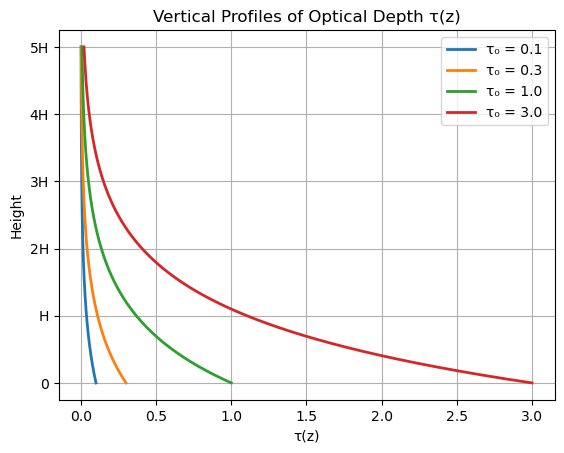

In [244]:
for i in tau_0:
    tau = vertical_profile(z=z, p_0=i, H=H)
    plt.plot(tau, z, label=f"\u03c4\u2080 = {i}", linewidth=2)
plt.legend(loc='upper right')
plt.xlabel('\u03c4(z)')
plt.ylabel('Height')
plt.title('Vertical Profiles of Optical Depth \u03c4(z)')
plt.yticks([0, H, H*2, H*3, H*4, H*5], labels=["0", "H", "2H", "3H", "4H", "5H"])
plt.grid()
plt.savefig('figures/fig_1b.png')

## Question 2

**a)** Let T(z,∞) be the fraction of broadband flux (irradiance) emitted upward by a thin layer of the atmosphere at height z that is transmitted to space. Provide an expression for T(z,∞) as a function of τ(z), r, and any other necessary parameters.

**b)** On one plot, show how T(z,∞) varies with z in the range 0 ≤ z ≤ 5H for r = 1.66 and τ₀ = 0.1, τ₀ = 0.3, τ₀ = 1, and τ₀ = 3.

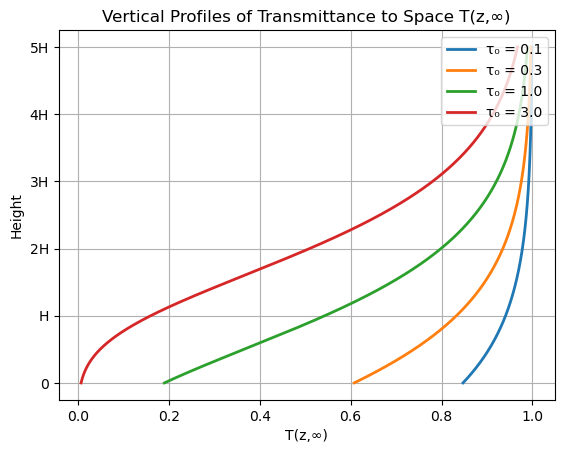

In [245]:
for i in tau_0:
    tau = vertical_profile(z=z, p_0=i, H=H)
    transmitted_flux = transmittance(tau, r)
    plt.plot(transmitted_flux, z, label=f"\u03c4\u2080 = {i}", linewidth=2)
plt.legend(loc='upper right')
plt.xlabel('T(z,\u221e)')
plt.ylabel('Height')
plt.title('Vertical Profiles of Transmittance to Space T(z,\u221e)')
plt.yticks([0, H, H*2, H*3, H*4, H*5], labels=["0", "H", "2H", "3H", "4H", "5H"])
plt.grid()
plt.savefig('figures/fig_2b.png')

## Question 3

**a)** Let B₀ be the amount of broadband hemispheric flux (irradiance) emitted upward by the surface, which can be approximated as a blackbody at terrestrial wavelengths. Let surface temperature be T₀. Provide an expression for B₀ as a function of T₀ and any other necessary parameters.

**b)** Let B₀(∞) be the amount of broadband flux (irradiance) emitted upward by the surface that is transmitted to space. Provide an expression for B₀(∞) as a function of T₀, τ(z), r, and any other necessary parameters.

**c)** Calculate values of B₀(∞) / σT₀⁴ for r = 1.66 and τ₀ = 0.1, τ₀ = 0.3, τ₀ = 1, and τ₀ = 3.

In [246]:
for i in tau_0:
    tau = vertical_profile(z=z, p_0=i, H=H)
    surface_flux = black_body_flux(temp=T_SFC)
    surface_flux_inf = transmitted_surface_flux(t_0=T_SFC, t_z=tau, r=r)
    surface_flux_inf_norm = surface_flux_inf / surface_flux
    print(f"\u03c4\u2080 = {i}, B\u2080(\u221e) / \u03c3T\u2080\u2074 = {surface_flux_inf_norm:.6f}")

τ₀ = 0.1, B₀(∞) / σT₀⁴ = 0.847046
τ₀ = 0.3, B₀(∞) / σT₀⁴ = 0.607745
τ₀ = 1.0, B₀(∞) / σT₀⁴ = 0.190139
τ₀ = 3.0, B₀(∞) / σT₀⁴ = 0.006874


## Question 4

**a)** Consider a thin layer of the atmosphere at height z that has optical thickness Δτ, where Δτ << 1. Let A(z) be the fraction of broadband flux (irradiance) upwelling from below directly into the layer that is absorbed (the absorptivity of the layer). Provide an expression for A(z) as a function of Δτ, r, and any other necessary parameters as the leading term of a Taylor series.

**b)** Let Δz be the geometrical thickness of the thin atmospheric layer, where Δz/H << 1. Provide an expression for A(z) as a function of Δz, τ(z), r, and any other necessary parameters as the leading term of a Taylor series.

**c)** On one plot, show how A(z) varies with z in the range 0 ≤ z ≤ 5H for r = 1.66 and τ₀ = 0.1, τ₀ = 0.3, τ₀ = 1, and τ₀ = 3. Specify what value of Δz/H you used.

dz/H = -0.0125


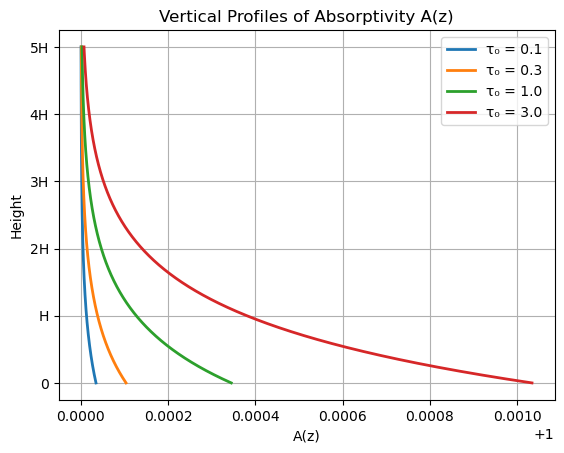

In [247]:
print(f"dz/H = {dz/H:.4f}")
for i in tau_0:
    const = -r * i / H
    tau = vertical_profile(z=z, p_0=const, H=H)
    A_z = transmittance(tau, r)
    plt.plot(A_z, z, label=f"\u03c4\u2080 = {i}", linewidth=2)
plt.legend(loc='upper right')
plt.xlabel('A(z)')
plt.ylabel('Height')
plt.title('Vertical Profiles of Absorptivity A(z)')
plt.yticks([0, H, H*2, H*3, H*4, H*5], labels=["0", "H", "2H", "3H", "4H", "5H"])
plt.grid()
plt.savefig('figures/fig_4c.png')

## Question 5

**a)** Let B(z) be the amount of broadband hemispheric flux (irradiance) emitted upward by a thin atmospheric layer at height z with geometric thickness Δz, where Δz/H << 1. For simplicity, assume atmospheric temperature T₀ is uniform. Let the emissivity of the layer be ε(z). Provide an expression for B(z) as a function of T₀, atmospheric emissivity ε(z), and any other necessary parameters.

**b)** Provide an expression for atmospheric emissivity ε(z) as a function of Δz, τ(z), r, and any other necessary parameters as the leading term of a Taylor series.

**c)** Let B(z,∞) be the amount of broadband flux (irradiance) emitted upward by a thin atmospheric layer at height z that is transmitted to space. Provide an expression for B(z,∞) as a function of T₀, Δz, τ(z), r, and any other necessary parameters.

**d)** Provide an expression for the value of τ_max(z) at which the amount of broadband flux emitted by a thin atmospheric layer that is transmitted to space is maximum. Assume that Δz is constant.

**e)** Provide an expression for the value of z_max/H at which the amount of broadband flux emitted by a thin atmospheric layer that is transmitted to space is maximum.

**f)** Let T(z_max,∞) be the fraction of broadband flux (irradiance) emitted upward by a thin layer of the atmosphere at height z_max that is transmitted to space. Provide an expression for T(z_max,∞) as a function of any necessary parameters.

**g)** Let ε(z_max) be the atmospheric emissivity at height z_max. Provide an expression for ε(z_max) as a function of Δz and any other necessary parameters.

**h)** Calculate values of z_max/H for r = 1.66 and τ₀ = 0.1, τ₀ = 0.3, τ₀ = 1, and τ₀ = 3. Note that if rτ₀ ≤ 1, maximum emission to space occurs at the surface.

**i)** On one plot, show how the ratio B(z,∞) / σT₀⁴ varies with z in the range 0 ≤ z ≤ 5H for r = 1.66 and τ₀ = 0.1, τ₀ = 0.3, τ₀ = 1, and τ₀ = 3. Specify what value of Δz/H you used. Verify that your various calculations and plots are consistent.

In [248]:
z_max_scaled(r=1.66, t_0=tau_0)

array([-1.79576749, -0.6971552 ,  0.5068176 ,  1.60542989])

dz/H = -0.0125


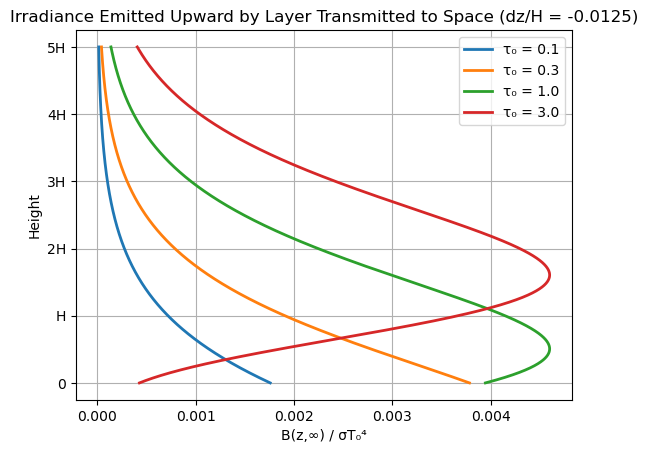

In [249]:
print(f"dz/H = {dz/H:.4f}")
for i in tau_0:
    B_layer = B_z_inf(T0=T_SFC, r=r, dz=dz, t_0=i, z=z, H=H)
    surface_flux = black_body_flux(temp=T_SFC)
    B_layer_normed = B_layer / surface_flux
    plt.plot(B_layer_normed, z, label=f"\u03c4\u2080 = {i}", linewidth=2)
plt.legend(loc='upper right')
plt.xlabel('B(z,\u221e) / \u03c3T\u2080\u2074')
plt.ylabel('Height')
plt.title(f'Irradiance Emitted Upward by Layer Transmitted to Space (dz/H = {dz/H:.4f})')
plt.yticks([0, H, H*2, H*3, H*4, H*5], labels=["0", "H", "2H", "3H", "4H", "5H"])
plt.grid()
plt.savefig('figures/fig_5i.png')

## Question 6

Using the model for the atmosphere developed for the previous questions, consider what will immediately happen if the absorber mixing ratio in the atmosphere suddenly increases.

**a)** Will τ₀ increase, decrease, or remain the same?

**b)** Will τ_max(z) increase, decrease, or remain the same?

**c)** Will z_max/H increase, decrease, or remain the same?

**d)** Will T(z_max,∞) increase, decrease, or remain the same?

**e)** Will the fraction of broadband flux emitted by the surface and transmitted to space increase, decrease, or remain the same?

**f)** Will the fraction of broadband flux emitted at height z_max and transmitted to space increase, decrease, or remain the same?

**g)** Will the emissivity of a thin atmospheric layer at height z_max increase, decrease, or remain the same?

**h)** Treating a thin atmospheric layer at height z_max as a blackbody, will the amount of broadband flux emitted at height z_max increase, decrease, or remain the same if atmospheric temperature monotonically decreases with height above the surface?

**i)** Treating a thin atmospheric layer at height z_max as a blackbody, will the amount of broadband flux emitted at height z_max increase, decrease, or remain the same if atmospheric temperature monotonically increases with height above the surface?

**j)** Under what condition will the greenhouse effect of an atmosphere become weaker when absorber mixing ratio increases?

## Question 7

**a)** Let T(z,0) be the fraction of broadband flux (irradiance) emitted downward by a thin layer of the atmosphere at height z that is transmitted to the surface. Provide an expression for T(z,0) as a function of τ(z), r, and any other necessary parameters.

**b)** On one plot, show how T(z,0) varies with z in the range 0 ≤ z ≤ 5H for r = 1.66 and τ₀ = 0.1, τ₀ = 0.3, τ₀ = 1, and τ₀ = 3.

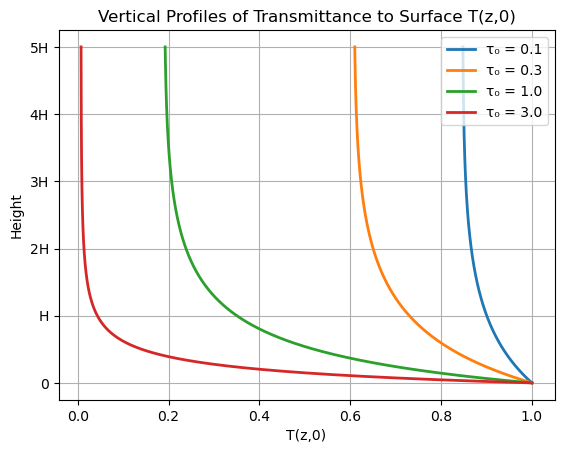

In [250]:
for i in tau_0:
    tau = tau_down(z=z, p_0=i, H=H)
    transmitted_flux = transmittance(tau, r)
    plt.plot(transmitted_flux, z, label=f"\u03c4\u2080 = {i}", linewidth=2)
plt.legend(loc='upper right')
plt.xlabel('T(z,0)')
plt.ylabel('Height')
plt.title('Vertical Profiles of Transmittance to Surface T(z,0)')
plt.yticks([0, H, H*2, H*3, H*4, H*5], labels=["0", "H", "2H", "3H", "4H", "5H"])
plt.grid()
plt.savefig('figures/fig_7b.png')

## Question 8

**a)** Let B(z,0) be the amount of broadband flux (irradiance) emitted downward by a thin atmospheric layer at height z that is transmitted to the surface. For this problem, assume that atmospheric temperature T₀ is uniform. Provide an expression for B(z,0) as a function of T(z,0), T₀, ε(z), and any other necessary parameters.

**b)** On one plot, show how the ratio B(z,0) / σT₀⁴ varies with z in the range 0 ≤ z ≤ 5H for r = 1.66 and τ₀ = 0.1, τ₀ = 0.3, τ₀ = 1, and τ₀ = 3. Specify what value of Δz/H you used. Note that the vertical profile of emission to the surface does not vary monotonically with τ₀.

dz/H = -0.0125


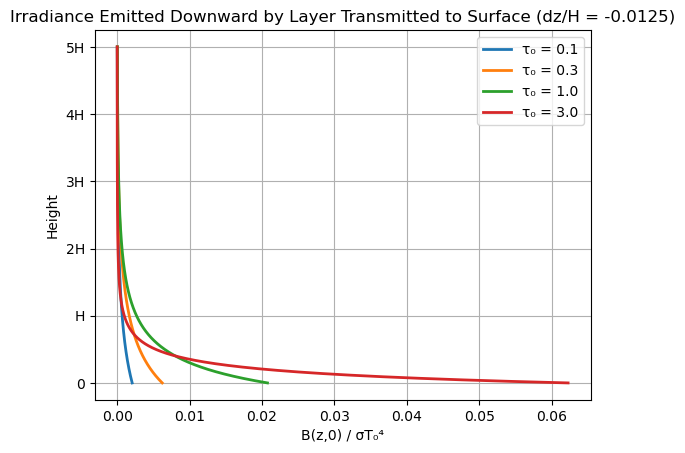

In [251]:
print(f"dz/H = {dz/H:.4f}")
for i in tau_0:
    B_layer = B_z_sfc(T0=T_SFC, r=r, dz=dz, t_0=i, z=z, H=H)
    surface_flux = black_body_flux(temp=T_SFC)
    B_layer_normed = B_layer / surface_flux
    plt.plot(B_layer_normed, z, label=f"\u03c4\u2080 = {i}", linewidth=2)
plt.legend(loc='upper right')
plt.xlabel('B(z,0) / \u03c3T\u2080\u2074')
plt.ylabel('Height')
plt.title(f'Irradiance Emitted Downward by Layer Transmitted to Surface (dz/H = {dz/H:.4f})')
plt.yticks([0, H, H*2, H*3, H*4, H*5], labels=["0", "H", "2H", "3H", "4H", "5H"])
plt.grid()
plt.savefig('figures/fig_8b.png')

## Questions 9–11: 1×CO₂ vs 2×CO₂

We will now apply the model to investigate differences in radiation flux between an atmosphere with 1×CO₂ concentration and an atmosphere with 2×CO₂ concentration. In both cases, assume surface temperature Tₛ = 288 K and temperature varies linearly with height: T(z) = Tₛ − γz/H. With scale height H = 8 km and lapse rate 6.5 K km⁻¹, γ = 52 K. Use τ₀ = 2.2 for 1×CO₂ and τ₀ = 2.3 for 2×CO₂.

## Question 9

**a)** Let B(z,0) be the amount of flux emitted downward by a thin atmospheric layer at height z that is transmitted to the surface. Plot how B(z,0) varies with z in the range 0 ≤ z ≤ 5H for Tₛ = 288 K, γ = 52 K, r = 1.66, and τ₀ = 2.2 (units W m⁻² per layer). Specify what value of Δz/H you used.

**b)** Ignoring the negligible contribution from z > 5H, summing over the emitted radiation that is transmitted to the surface by all layers yields the total downward flux from the atmosphere to the surface (units W m⁻²). Calculate this value.

**c)** Imagine that the absorber mixing ratio suddenly increases and τ₀ changes from 2.2 to 2.3 but temperature remains the same. Calculate B(z,0) for Tₛ = 288 K, γ = 52 K, r = 1.66, and τ₀ = 2.3. Plot how the change in flux B(z,0,τ=2.3) − B(z,0,τ=2.2) varies with z in the range 0 ≤ z ≤ 5H. Specify what value of Δz/H you used.

**d)** Ignoring the negligible contribution from z > 5H, calculate the change in total downward flux at the surface.

**e)** Briefly explain the physical mechanism(s) responsible for the difference plot and change in total downward flux to the surface.

dz/H = -0.0125
Total downward atmospheric flux at surface (1×CO₂): -378.4452 W m⁻²


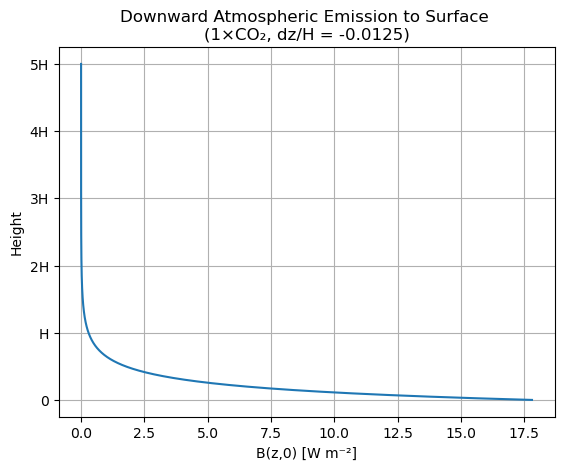

In [252]:
print(f"dz/H = {dz/H:.4f}")
df_down = pd.DataFrame({'height': z, 'temperature': temp_profile(T0=TS, z=z)})
df_down['Bz_1xco2'] = df_down.apply(
    lambda x: B_z_sfc(T0=x['temperature'], r=r, dz=dz, t_0=TAU_0_1, z=x['height'], H=H), axis=1)
df_down['Bz_2xco2'] = df_down.apply(
    lambda x: B_z_sfc(T0=x['temperature'], r=r, dz=dz, t_0=TAU_0_2, z=x['height'], H=H), axis=1)

print(f"Total downward atmospheric flux at surface (1\u00d7CO\u2082): {df_down['Bz_1xco2'].sum()*(dz/H):.4f} W m\u207b\u00b2")
plt.plot(df_down['Bz_1xco2'], z)
plt.yticks([0, H, H*2, H*3, H*4, H*5], labels=["0", "H", "2H", "3H", "4H", "5H"])
plt.title(f'Downward Atmospheric Emission to Surface \n(1\u00d7CO\u2082, dz/H = {dz/H:.4f})')
plt.xlabel('B(z,0) [W m\u207b\u00b2]')
plt.ylabel('Height')
plt.grid()
plt.savefig('figures/fig_9a.png')

In [253]:
print(df_down['Bz_1xco2'].sum())
print(df_down['Bz_1xco2'].sum()*dz/H)

30275.61213839124
-378.4451517298905


Change in total downward flux at surface: 392.8873 W m⁻²


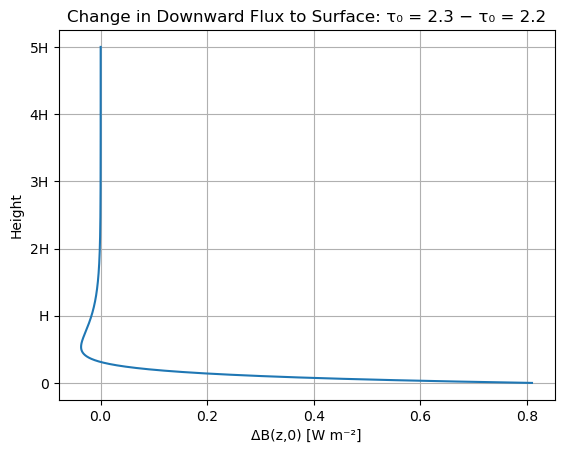

In [254]:
print(f"Change in total downward flux at surface: {(df_down['Bz_2xco2'] - df_down['Bz_1xco2']).sum():.4f} W m\u207b\u00b2")
plt.plot(df_down['Bz_2xco2'] - df_down['Bz_1xco2'], z)
plt.yticks([0, H, H*2, H*3, H*4, H*5], labels=["0", "H", "2H", "3H", "4H", "5H"])
plt.title('Change in Downward Flux to Surface: \u03c4\u2080 = 2.3 \u2212 \u03c4\u2080 = 2.2')
plt.xlabel('\u0394B(z,0) [W m\u207b\u00b2]')
plt.ylabel('Height')
plt.grid()
plt.savefig('figures/fig_9c.png')

In [255]:
print((df_down['Bz_2xco2'] - df_down['Bz_1xco2']).sum())
print((df_down['Bz_2xco2'] - df_down['Bz_1xco2']).sum()*dz/H)

392.8873409491817
-4.911091761864771


## Question 10

**a)** Let B₀(∞) be the amount of flux emitted upward by the surface that is transmitted to space. Approximating the surface as a blackbody, calculate B₀(∞) if Tₛ = 288 K, r = 1.66, and τ₀ = 2.2.

**b)** Imagine that the absorber mixing ratio suddenly increases and τ₀ changes from 2.2 to 2.3 but surface temperature remains the same. Calculate B₀(∞) for Tₛ = 288 K, r = 1.66, and τ₀ = 2.3. Calculate the change in flux B₀(∞,τ=2.3) − B₀(∞,τ=2.2).

In [265]:
transmitted_surface_flux(t_0=TS, t_z=vertical_profile(z, TAU_0_2, H), r=r) - transmitted_surface_flux(t_0=TS, t_z=vertical_profile(z, TAU_0_1, H), r=r)

np.float64(-1.5477414507628282)

Change in total upward atmospheric flux: 112.1963 W m⁻²


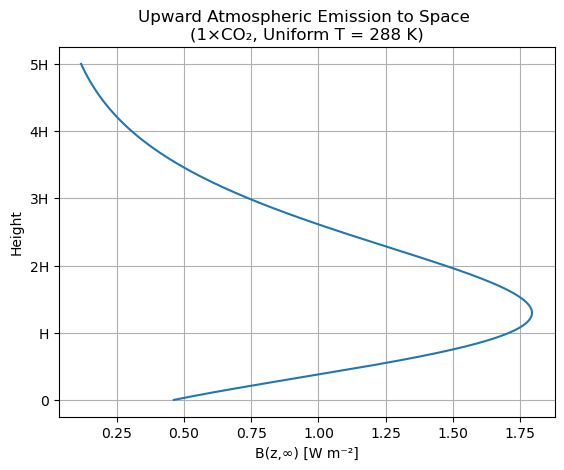

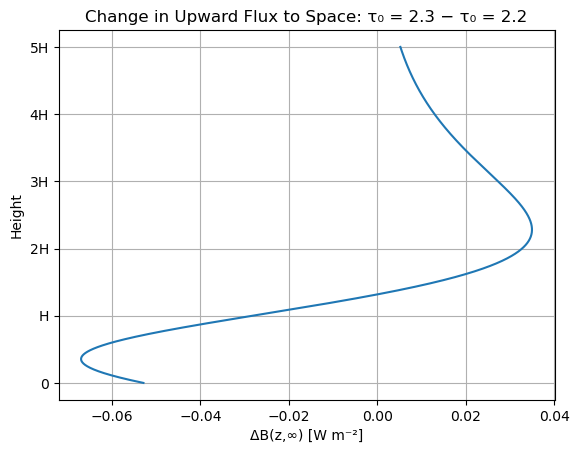

In [256]:
df_up = pd.DataFrame({'height': z, 'temperature': temp_profile(T0=TS, z=z)})
df_up['Bz_1xco2'] = df_up.apply(
    lambda x: B_z_inf(T0=TS, r=r, dz=dz, t_0=TAU_0_1, z=x['height'], H=H), axis=1)
df_up['Bz_2xco2'] = df_up.apply(
    lambda x: B_z_inf(T0=TS, r=r, dz=dz, t_0=TAU_0_2, z=x['height'], H=H), axis=1)

plt.plot(df_up['Bz_1xco2'], z)
plt.yticks([0, H, H*2, H*3, H*4, H*5], labels=["0", "H", "2H", "3H", "4H", "5H"])
plt.title('Upward Atmospheric Emission to Space \n(1\u00d7CO\u2082, Uniform T = 288 K)')
plt.xlabel('B(z,\u221e) [W m\u207b\u00b2]')
plt.ylabel('Height')
plt.grid()
plt.savefig('figures/fig_10a.png')
plt.figure()
print(f"Change in total upward atmospheric flux: {(df_up['Bz_2xco2'] - df_up['Bz_1xco2']).sum():.4f} W m\u207b\u00b2")
plt.plot(df_up['Bz_2xco2'] - df_up['Bz_1xco2'], z)
plt.yticks([0, H, H*2, H*3, H*4, H*5], labels=["0", "H", "2H", "3H", "4H", "5H"])
plt.title('Change in Upward Flux to Space: \u03c4\u2080 = 2.3 \u2212 \u03c4\u2080 = 2.2')
plt.xlabel('\u0394B(z,\u221e) [W m\u207b\u00b2]')
plt.ylabel('Height')
plt.grid()
plt.savefig('figures/fig_10b.png')

## Question 11

**a)** Let B(z,∞) be the amount of flux emitted upward by a thin atmospheric layer at height z that is transmitted to space. Plot how B(z,∞) varies with z in the range 0 ≤ z ≤ 5H for Tₛ = 288 K, γ = 52 K, r = 1.66, and τ₀ = 2.2 (units W m⁻² per layer). Specify what value of Δz/H you used.

**b)** Ignoring the negligible contribution from z > 5H, summing over the emitted radiation that is transmitted to space by all layers yields the total upward flux from the atmosphere to space (units W m⁻²). Calculate this value.

**c)** What is the total upward flux from the atmosphere and the surface to space?

**d)** Imagine that the absorber mixing ratio suddenly increases and τ₀ changes from 2.2 to 2.3. Calculate B(z,∞) for Tₛ = 288 K, γ = 52 K, r = 1.66, and τ₀ = 2.3. Plot how B(z,∞,τ=2.3) − B(z,∞,τ=2.2) varies with z in the range 0 ≤ z ≤ 5H. Specify what value of Δz/H you used.

**e)** Ignoring the negligible contribution from z > 5H, calculate the change in total upward flux from the atmosphere to space.

**f)** What is the change in the total upward flux from the atmosphere and the surface to space?

**g)** Briefly explain the physical mechanism(s) responsible for the difference plot and change in total upward flux from the atmosphere and surface to space.

Total upward atmospheric flux to space (1×CO₂): -136.5626 W m⁻²


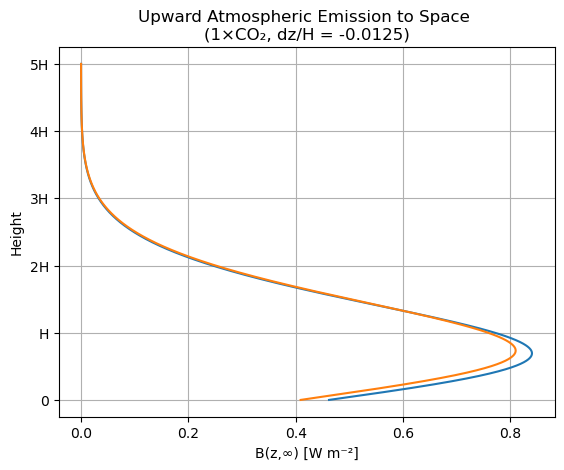

In [277]:
df_up['Bz_inf_1xco2'] = df_up.apply(
    lambda x: B_z_inf(T0=x['temperature'], r=r, dz=dz, t_0=TAU_0_1, z=x['height'], H=H), axis=1)
df_up['Bz_inf_2xco2'] = df_up.apply(
    lambda x: B_z_inf(T0=x['temperature'], r=r, dz=dz, t_0=TAU_0_2, z=x['height'], H=H), axis=1)

print(f"Total upward atmospheric flux to space (1\u00d7CO\u2082): {df_up['Bz_inf_1xco2'].sum()*dz/H:.4f} W m\u207b\u00b2")
plt.plot(df_up['Bz_inf_1xco2'], z)
plt.plot(df_up['Bz_inf_2xco2'], z)
plt.yticks([0, H, H*2, H*3, H*4, H*5], labels=["0", "H", "2H", "3H", "4H", "5H"])
plt.title(f'Upward Atmospheric Emission to Space \n(1\u00d7CO\u2082, dz/H = {dz/H:.4f})')
plt.xlabel('B(z,\u221e) [W m\u207b\u00b2]')
plt.ylabel('Height')
plt.grid()
plt.savefig('figures/fig_11a.png')

In [271]:
(df_up['Bz_inf_1xco2'].sum()*dz/H)*-1 + transmitted_surface_flux(t_0=TS, t_z=vertical_profile(z, TAU_0_1, H), r=r)

np.float64(146.68158568772884)

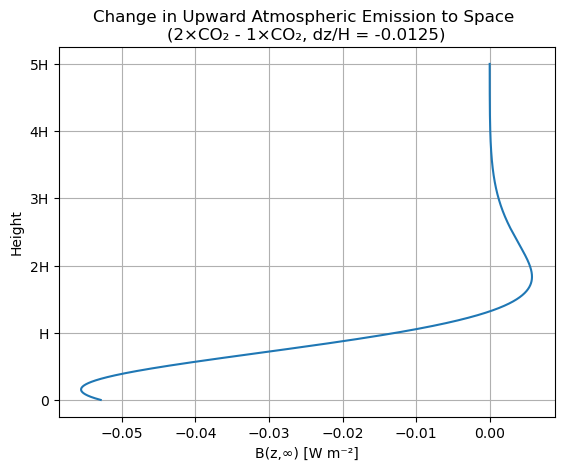

In [273]:
# df_up['Bz_inf_1xco2'] = df_up.apply(
#     lambda x: B_z_inf(T0=x['temperature'], r=r, dz=dz, t_0=TAU_0_1, z=x['height'], H=H), axis=1)
# df_up['Bz_inf_2xco2'] = df_up.apply(
#     lambda x: B_z_inf(T0=x['temperature'], r=r, dz=dz, t_0=TAU_0_2, z=x['height'], H=H), axis=1)

# print(f"Change in upward atmospheric flux to space (1\u00d7CO\u2082): {df_up['Bz_inf_1xco2'].sum()*dz/H:.4f} W m\u207b\u00b2")
plt.plot(df_up['Bz_inf_2xco2'] - df_up['Bz_inf_1xco2'], z)
plt.yticks([0, H, H*2, H*3, H*4, H*5], labels=["0", "H", "2H", "3H", "4H", "5H"])
plt.title(f'Change in Upward Atmospheric Emission to Space \n(2\u00d7CO\u2082 - 1\u00d7CO\u2082, dz/H = {dz/H:.4f})')
plt.xlabel('B(z,\u221e) [W m\u207b\u00b2]')
plt.ylabel('Height')
plt.grid()
plt.savefig('figures/fig_11d.png')

In [275]:
(df_up['Bz_inf_2xco2'] - df_up['Bz_inf_1xco2']).sum()*dz/H

np.float64(3.5453349623535524)

In [276]:
((df_up['Bz_inf_2xco2'].sum()*dz/H)*-1 + transmitted_surface_flux(t_0=TS, t_z=vertical_profile(z, TAU_0_2, H), r=r)) - ((df_up['Bz_inf_1xco2'].sum()*dz/H)*-1 + transmitted_surface_flux(t_0=TS, t_z=vertical_profile(z, TAU_0_1, H), r=r))

np.float64(-5.093076413116364)